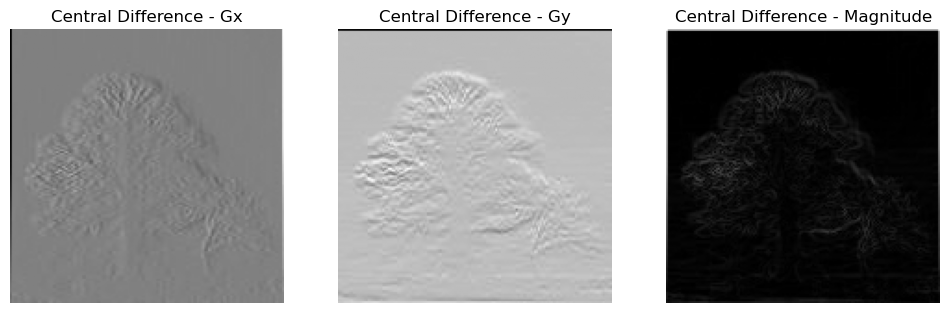

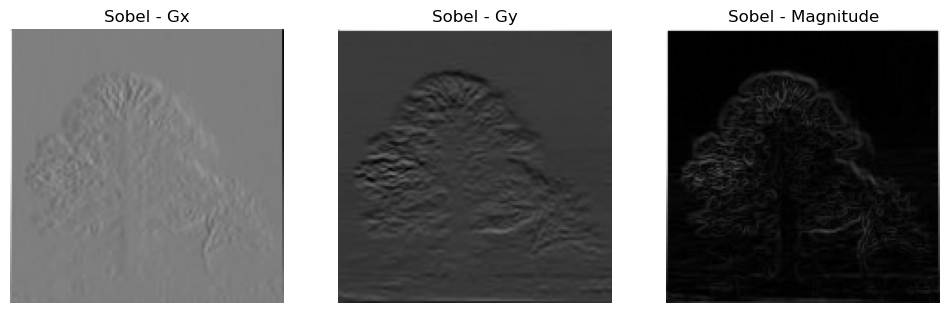

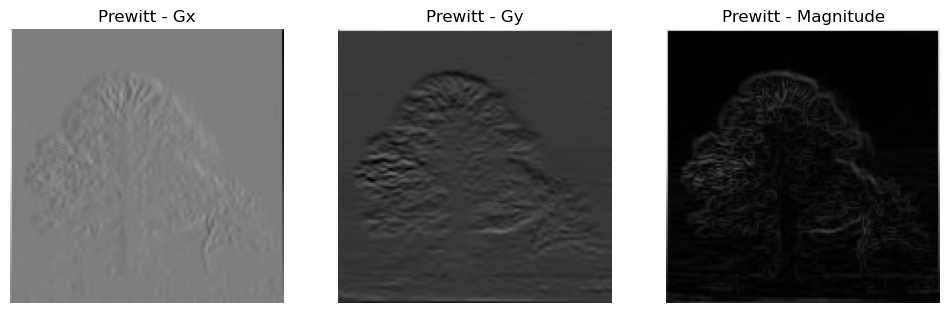

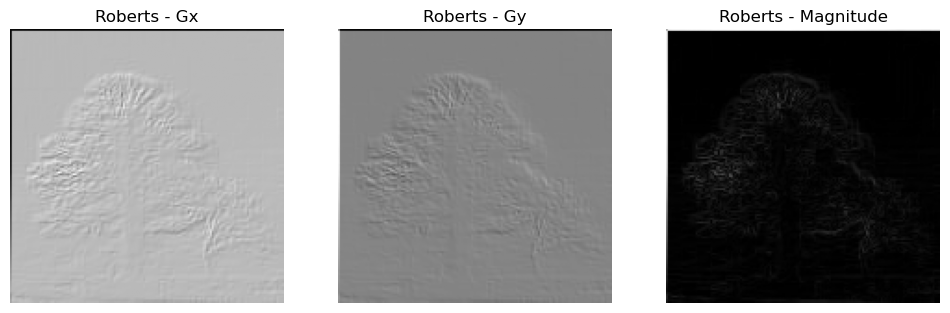

Comparison of Gradient Methods:

               Method Noise Sensitivity Edge Thickness       Accuracy  \
0  Central Difference              High           Thin          Basic   
1               Sobel               Low         Medium      Very Good   
2             Prewitt            Medium         Medium           Good   
3             Roberts         Very High      Very Thin  Less Accurate   

  Kernel Size  
0         1x3  
1         3x3  
2         3x3  
3         2x2  


In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# -----------------------------
# Helper Function: Convolution
# -----------------------------
def convolve(image, kernel):
    h, w = image.shape
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2
    
    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant')
    output = np.zeros_like(image, dtype=np.float32)
    
    for i in range(h):
        for j in range(w):
            region = padded[i:i+kh, j:j+kw]
            output[i, j] = np.sum(region * kernel)
    
    return output

# -----------------------------
# Load Grayscale Image
# -----------------------------
img_path = "image1.jpeg"  # change to your image path
if not os.path.exists(img_path):
    raise FileNotFoundError(f"Image not found at '{img_path}'")

img = cv2.imread(img_path, 0)
if img is None:
    raise ValueError(f"Failed to load image '{img_path}'")
img = img.astype(np.float32)

# -----------------------------
# Gradient Kernels
# -----------------------------
kernels = {
    "Central Difference": {
        "Gx": np.array([[1, 0, -1]]),
        "Gy": np.array([[1], [0], [-1]])
    },
    "Sobel": {
        "Gx": np.array([[-1, 0, 1],
                        [-2, 0, 2],
                        [-1, 0, 1]]),
        "Gy": np.array([[-1, -2, -1],
                        [ 0,  0,  0],
                        [ 1,  2,  1]])
    },
    "Prewitt": {
        "Gx": np.array([[-1, 0, 1],
                        [-1, 0, 1],
                        [-1, 0, 1]]),
        "Gy": np.array([[-1, -1, -1],
                        [ 0,  0,  0],
                        [ 1,  1,  1]])
    },
    "Roberts": {
        "Gx": np.array([[1, 0],
                        [0, -1]]),
        "Gy": np.array([[0, 1],
                        [-1, 0]])
    }
}

# -----------------------------
# Compute Gradients, Magnitude, Direction
# -----------------------------
results = {}

for method, kernel in kernels.items():
    gx = convolve(img, kernel["Gx"])
    gy = convolve(img, kernel["Gy"])
    magnitude = np.sqrt(gx**2 + gy**2)
    direction = np.arctan2(gy, gx)
    
    results[method] = {
        "Gx": gx,
        "Gy": gy,
        "Magnitude": magnitude,
        "Direction": direction
    }

# -----------------------------
# Visualization Function
# -----------------------------
def visualize(method, data):
    plt.figure(figsize=(12,4))
    
    plt.subplot(1,3,1)
    plt.imshow(data["Gx"], cmap='gray')
    plt.title(f"{method} - Gx")
    plt.axis('off')
    
    plt.subplot(1,3,2)
    plt.imshow(data["Gy"], cmap='gray')
    plt.title(f"{method} - Gy")
    plt.axis('off')
    
    plt.subplot(1,3,3)
    plt.imshow(data["Magnitude"], cmap='gray')
    plt.title(f"{method} - Magnitude")
    plt.axis('off')
    
    plt.show()

# -----------------------------
# Show Results for All Methods
# -----------------------------
for method, data in results.items():
    visualize(method, data)

# -----------------------------
# Comparison Observations
# -----------------------------
comparison_table = {
    "Method": ["Central Difference", "Sobel", "Prewitt", "Roberts"],
    "Noise Sensitivity": ["High", "Low", "Medium", "Very High"],
    "Edge Thickness": ["Thin", "Medium", "Medium", "Very Thin"],
    "Accuracy": ["Basic", "Very Good", "Good", "Less Accurate"],
    "Kernel Size": ["1x3", "3x3", "3x3", "2x2"]
}

import pandas as pd
df = pd.DataFrame(comparison_table)
print("Comparison of Gradient Methods:\n")
print(df)
